In [1]:

import sys 
sys.path.append("/om/user/akiruga/diffsplatimg3d/huggingface-stable-diffusion")
import os
import math
import json
import argparse
from pathlib import Path
from datetime import datetime

import numpy as np
from PIL import Image

import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt

import torch
from diffusers import DDPMScheduler
from diffusers.models import UNet3DConditionModel

import binvox_rw
from tqdm import tqdm

In [2]:

def get_attention_hidden_states(model: UNet3DConditionModel, batch_size: int, device: torch.device) -> torch.Tensor:
    """Create dummy zero conditioning matching training behavior.
    If the model has no cross-attention, we still pass a (B,1,1) tensor.
    """
    cond_dim = getattr(model, "config", None)
    cond_dim = getattr(cond_dim, "cross_attention_dim", None) if cond_dim is not None else None
    cond_dim = cond_dim if cond_dim is not None else 1
    return torch.zeros((batch_size, 1, cond_dim), device=device, dtype=torch.float32)


def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def save_binvox(volume_bool: np.ndarray, out_path: Path) -> None:
    assert volume_bool.dtype == np.bool_, "Expected boolean array for binvox."
    dims = list(volume_bool.shape)
    vox = binvox_rw.Voxels(volume_bool, dims=dims, translate=[0.0, 0.0, 0.0], scale=1.0, axis_order="xyz")
    with open(out_path, "wb") as f:
        vox.write(f)


def vox_frame(vol_dhw: np.ndarray, thr: float = 0.0) -> np.ndarray:
    # first rot 90 degrees 
    vol_dhw = np.rot90(vol_dhw, k=1, axes=(1, 2))
    occ = (vol_dhw > thr)
    fig = plt.figure(figsize=(3, 3), dpi=256 // 3)
    ax = fig.add_subplot(111, projection="3d")
    ax.voxels(occ, facecolors="#888888", edgecolor="black", linewidth=0.1)
    ax.set_axis_off()
    ax.view_init(25, 45)
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    img = np.frombuffer(fig.canvas.tostring_rgb(), np.uint8).reshape(h, w, 3).copy()
    plt.close(fig)
    return img


@torch.no_grad()
def reverse_diffusion(unet: UNet3DConditionModel,
                      scheduler: DDPMScheduler,
                      batch_size: int,
                      voxel_size: int,
                      num_inference_steps: int,
                      device: torch.device) -> torch.Tensor:
    scheduler.set_timesteps(num_inference_steps, device=device)
    x = torch.randn((batch_size, 1, voxel_size, voxel_size, voxel_size), device=device)
    # Match training: always provide dummy zero conditioning, even if cross-attention is disabled
    enc_hid = get_attention_hidden_states(unet, batch_size, device)

    for t in tqdm(scheduler.timesteps, desc="Reverse diffusion"):
        eps = unet(x, t, encoder_hidden_states=enc_hid).sample
        x = scheduler.step(model_output=eps, timestep=t, sample=x).prev_sample

    return x.clamp(-1, 1)


In [3]:
class Args: 
    pass 

args = Args()

args.ckpt_dir = "/om/user/akiruga/diffsplatimg3d/huggingface-stable-diffusion/ddpm-vox-03001627-32"
args.num_samples = 8
args.batch_size = min(args.num_samples, 32)
args.num_inference_steps = 250
args.threshold = 0.0
args.out_dir = "/om/user/akiruga/diffsplatimg3d/huggingface-stable-diffusion/viz"
args.save_binvox = False
args.seed = 0

out_root = Path(args.out_dir) if args.out_dir else (ckpt_dir / "inference" / datetime.now().strftime("%Y%m%d-%H%M%S"))
img_dir = out_root / "images"
vox_dir = out_root / "binvox"
ensure_dir(img_dir)
ensure_dir(vox_dir)

In [4]:
set_seed(args.seed)

ckpt_dir = Path(args.ckpt_dir)
unet_dir = ckpt_dir / "unet"
sched_dir = ckpt_dir / "scheduler"

assert unet_dir.is_dir(), f"Missing {unet_dir}"
assert sched_dir.is_dir(), f"Missing {sched_dir}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

unet = UNet3DConditionModel.from_pretrained(unet_dir).to(device)
print(f"Loaded UNet from {unet_dir}")
unet.eval()
scheduler = DDPMScheduler.from_pretrained(sched_dir)
print(f"Loaded scheduler from {sched_dir}")

voxel_size = unet.config.sample_size
assert isinstance(voxel_size, int), f"Unexpected sample_size: {voxel_size}"
print(f"Voxel size: {voxel_size}")


Using device: cuda
Loaded UNet from /om/user/akiruga/diffsplatimg3d/huggingface-stable-diffusion/ddpm-vox-03001627-32/unet
Loaded scheduler from /om/user/akiruga/diffsplatimg3d/huggingface-stable-diffusion/ddpm-vox-03001627-32/scheduler
Voxel size: 32


In [5]:
remaining = args.num_samples
bs = max(1, args.batch_size)
sample_idx = 0

imgs = []
binvoxes = []

loops = math.ceil(remaining / bs)
for _ in range(loops): 
    cur_bs = min(bs, remaining)
    vols = reverse_diffusion(unet, scheduler, cur_bs, voxel_size, args.num_inference_steps, device)  # (B,1,D,H,W)
    vols_np = vols.squeeze(1).detach().cpu().numpy()  # (B,D,H,W)

    for i in tqdm(range(cur_bs), desc="Saving samples"):
        png_name = f"sample_{sample_idx:05d}.png"
        img = vox_frame(vols_np[i], thr=args.threshold)
        imgs.append(img)
        bv_name = f"sample_{sample_idx:05d}.binvox"
        bv_path = vox_dir / bv_name
        # save the binvox 
        # save_binvox((vols_np[i] > args.threshold).astype(np.bool_), bv_path)
        binvoxes.append(vols_np[i])


    remaining -= cur_bs
    print(f"[infer] generated {sample_idx}/{args.num_samples}")



Saving samples:   0%|                                                                              | 0/8 [00:00<?, ?it/s]/tmp/ipykernel_884501/1023285051.py:42: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), np.uint8).reshape(h, w, 3).copy()
Saving samples: 100%|██████████████████████████████████████████████████████████████████████| 8/8 [00:35<00:00,  4.41s/it]

[infer] generated 0/8


In [6]:
# # convert list of np arrays to torch tensor 

# import torch 
# import numpy as np 

imgs = np.array(imgs)
imgs = torch.from_numpy(imgs)/255.0
imgs = imgs.permute(0, 3, 1, 2)


# visualize imgs with torchvision grid 
import torchvision.utils as vutils

grid = vutils.make_grid(imgs.float(), nrow=4)
vutils.save_image(grid, "grid.png")

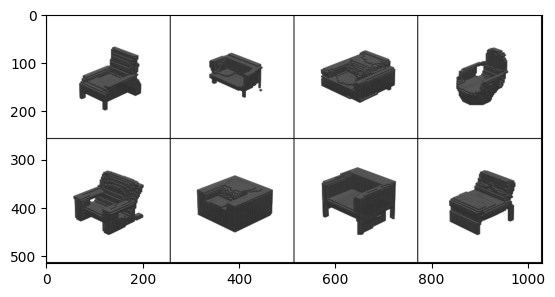

In [7]:
# plot the grid of images 

import matplotlib.pyplot as plt
import torchvision.utils as vutils

plt.imshow(grid.permute(1, 2, 0))
plt.show()

# Inference

## Sampling with ShapeNet

In [8]:
import depth_pro
import os 
import sys 

# Load model and preprocessing transform
model, transform = depth_pro.create_model_and_transforms()
model.eval()

DepthPro(
  (encoder): DepthProEncoder(
    (patch_encoder): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linea

### Segmentation

final text_encoder_type: bert-base-uncased


SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


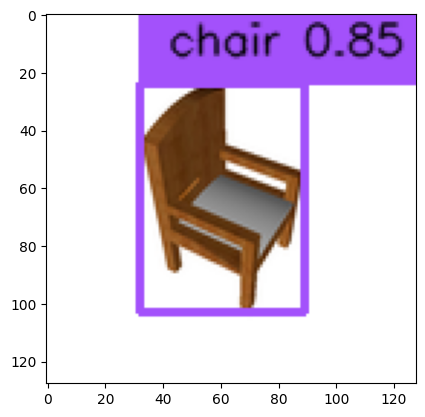

In [69]:
from groundingdino.util.inference import load_model, load_image, predict, annotate
import cv2
import matplotlib.pyplot as plt
GSA_path = "/om/user/akiruga/Grounded-Segment-Anything"
# chair_img_path = "/om/user/akiruga/datasets/ShapeNetRendering/03001627/597f2b2153af0c544aabcf2a7cb640f9/rendering/00.png"
# chair_img_path = "/om/user/akiruga/datasets/ShapeNetRendering/03001627/1a8bbf2994788e2743e99e0cae970928/rendering/05.png"
chair_img_path = "/om/user/akiruga/datasets/srn_chairs_alternate_views/1a8bbf2994788e2743e99e0cae970928/side-top/rgb/000022.png"

IMAGE_PATH = chair_img_path
TEXT_PROMPT = "chair."
BOX_THRESHOLD = 0.3
TEXT_THRESHOLD = 0.25
gsa_model = load_model(GSA_path + "/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py", GSA_path + "/groundingdino_swint_ogc.pth")
image_source, image = load_image(IMAGE_PATH)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# run Grounding DINO for detection 


boxes, logits, phrases = predict(
    model=gsa_model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD, 
    device=device
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
# change bgr to rgb 
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
plt.imshow(annotated_frame)
plt.show()

In [ ]:
# segment 
# sam predictor 
from segment_anything import build_sam, SamPredictor 

import torch

# load the model 
sam_checkpoint = GSA_path + "/sam_vit_h_4b8939.pth"
sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=device)
sam_predictor = SamPredictor(sam)


In [35]:
image.shape, image_source.shape

(torch.Size([3, 800, 800]), (137, 137, 3))

In [36]:
# run segment anything 
from groundingdino.util import box_ops

sam_predictor.set_image(image_source)
H, W = image_source.shape[:2]
boxes_xyxy = box_ops.box_cxcywh_to_xyxy(boxes) * torch.Tensor([W, H, W, H])

transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_xyxy, image_source.shape[:2]).to(device)
masks, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

In [37]:
type(masks), masks.shape, image_source.shape, H, W

(torch.Tensor, torch.Size([1, 1, 137, 137]), (137, 137, 3), 137, 137)

In [ ]:
def show_mask(mask, image, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.8])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    
    print(image.shape, mask_image.shape)
    
    annotated_frame_pil = Image.fromarray(image).convert("RGBA")
    mask_image_pil = Image.fromarray((mask_image.cpu().numpy() * 255).astype(np.uint8)).convert("RGBA")

    return np.array(Image.alpha_composite(annotated_frame_pil, mask_image_pil))

annotated_frame_with_mask = show_mask(masks[0][0].cpu(), annotated_frame)


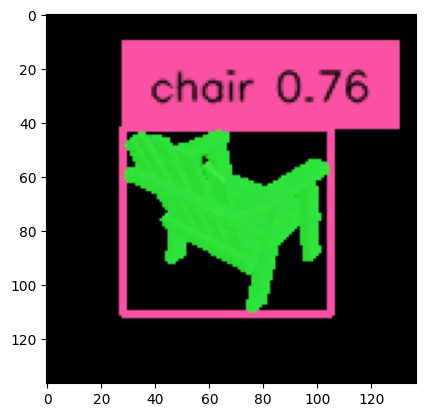

In [41]:
plt.imshow(annotated_frame_with_mask)
plt.show()

### depth

In [63]:
chair_img_path = "/om/user/akiruga/datasets/ShapeNetRendering/03001627/597f2b2153af0c544aabcf2a7cb640f9/rendering/04.png"
# Load and preprocess an image.
image, _, f_px = depth_pro.load_rgb(chair_img_path)
image = transform(image)

# Run inference.
prediction = model.infer(image, f_px=f_px)
depth = prediction["depth"]  # Depth in [m].
focallength_px = prediction["focallength_px"]  # Focal length in pixels.


KeyboardInterrupt: 

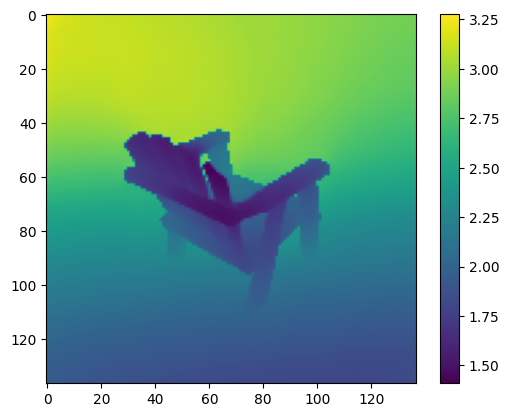

In [ ]:
# visualize viridis the depth map 
import matplotlib.pyplot as plt
import numpy as np


plt.imshow(depth, cmap="viridis")
plt.colorbar()
plt.show()

In [18]:
masks[0][0]

NameError: name 'masks' is not defined

In [52]:
depth = depth.cpu()
seg_mask = masks[0][0].cpu()
# we need to turn depth into a segmented depth map 
# then turn segmented depth map into a point cloud 

segmented_depth = depth * seg_mask

# turn it into x,y,z


In [19]:
from dataclasses import dataclass
from typing import Optional, Union, List
@dataclass
class Intrin:
    fx: Union[float, torch.Tensor]
    fy: Union[float, torch.Tensor]
    cx: Union[float, torch.Tensor]
    cy: Union[float, torch.Tensor]

    def scale(self, scaling: float):
        return Intrin(
                    self.fx * scaling,
                    self.fy * scaling,
                    self.cx * scaling,
                    self.cy * scaling
                )

    def get(self, field:str, image_id:int=0):
        val = self.__dict__[field]
        return val if isinstance(val, float) else val[image_id].item()


In [20]:
import numpy as np

def depth_to_pcd(depth, seg_mask, K, pose_wc=None, rgb=None):
    """
    Convert a (H,W) depth map + binary seg_mask into a point cloud.
    depth:   (H,W) array of depths (meters)
    seg_mask:(H,W) bool/0-1 mask (True = keep)
    K:       3x3 intrinsics or tuple (fx, fy, cx, cy)
    pose_wc: optional 4x4 world-from-camera pose. If None, returns camera-frame points.
    rgb:     optional (H,W,3) uint8/float image to sample colors

    Returns:
      points: (N,3) ndarray
      colors: (N,3) ndarray or None
      idx:    (N,2) pixel indices (v,u)
    
    Example: 
    segmented_depth is just depth * seg_mask, but you only need depth + seg_mask here.
    K can be a 3x3 matrix or (fx, fy, cx, cy).
    points_cam, colors, pix = depth_to_pcd(depth, seg_mask, K, pose_wc=None, rgb=rgb_image)
    """
    if isinstance(K, (list, tuple, np.ndarray)) and np.array(K).shape == (3,3):
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    elif isinstance(K, Intrin):
        fx, fy, cx, cy = K.fx, K.fy, K.cx, K.cy
    else:
        fx, fy, cx, cy = K

    depth = np.asarray(depth)
    seg_mask = np.asarray(seg_mask).astype(bool)

    H, W = depth.shape
    u = np.arange(W)
    v = np.arange(H)
    uu, vv = np.meshgrid(u, v)  # (H,W)

    valid = seg_mask & np.isfinite(depth) & (depth > 0)
    if not np.any(valid):
        return np.empty((0,3)), None, np.empty((0,2), dtype=int)

    Z = depth[valid]
    X = (uu[valid] - cx) * Z / fx
    Y = (vv[valid] - cy) * Z / fy
    points = np.stack([X, Y, Z], axis=-1)  # camera frame

    if pose_wc is not None:
        pose_wc = np.asarray(pose_wc)
        R = pose_wc[:3,:3]
        t = pose_wc[:3, 3]
        points = (points @ R.T) + t  # world frame

    colors = None
    if rgb is not None:
        rgb = np.asarray(rgb)
        colors = rgb[valid].reshape(-1, rgb.shape[-1])

    idx_v = vv[valid]
    idx_u = uu[valid]
    idx = np.stack([idx_v, idx_u], axis=-1).astype(int)
    return points, colors, idx



In [21]:
depth.shape, seg_mask.shape, segmented_depth.shape

NameError: name 'seg_mask' is not defined

## Point clouds from real image depth and segmentatino map

In [22]:
fov_degrees = 51.98948897809546  # From your config
fov_radians = fov_degrees * np.pi / 180.0
# image_size = 128  # Your actual image size
image_size = 137  # Your actual image size

# Calculate focal length from FOV: focal = (width/2) / tan(fov/2)
focal_length = (image_size / 2.0) / np.tan(fov_radians / 2.0)
principal_point = image_size / 2.0  # Center of image

print(f"  FOV: {fov_degrees} degrees = {fov_radians} radians")
print(f"  Image size: {image_size}x{image_size}")
print(f"  Calculated focal length: {focal_length}")
print(f"  Principal point: ({principal_point}, {principal_point})")

# Override the intrinsics with FOV-calculated values
intrins_full = Intrin(focal_length, focal_length, principal_point, principal_point)

  FOV: 51.98948897809546 degrees = 0.9073877590970678 radians
  Image size: 137x137
  Calculated focal length: 140.478515625
  Principal point: (68.5, 68.5)


In [62]:
points_cam, colors, pix = depth_to_pcd(depth, seg_mask, intrins_full, pose_wc=None, rgb=image_source)

In [ ]:
import numpy as np
import plotly.graph_objects as go

pts = np.asarray(points_cam)                    # (N,3)
cols = np.asarray(colors)                       # (N,3) uint8 or float
if cols.dtype != np.uint8:
    cols = (np.clip(cols, 0, 1) * 255).astype(np.uint8)
rgb_str = [f"rgb({r},{g},{b})" for r, g, b in cols]

fig = go.Figure(
    data=[go.Scatter3d(
        x=pts[:,0], y=pts[:,1], z=pts[:,2],
        mode="markers",
        marker=dict(size=1, color=rgb_str, opacity=1.0)
    )]
)
fig.update_layout(scene_aspectmode="data", margin=dict(l=0, r=0, t=0, b=0))
fig.show()


# Voxel rendering

In [73]:
binvoxes[0].shape, binvoxes[0].min(), binvoxes[0].max()

((32, 32, 32), -0.93843937, 1.0)

In [59]:
# --- camera helpers (device-safe) ---
import math, torch

def look_at(eye, target, up=None):
    device = eye.device
    if up is None:
        up = torch.tensor([0., -1., 0.], device=device)
    f = (target - eye); f = f / (f.norm() + 1e-9)
    r = torch.cross(f, up); r = r / (r.norm() + 1e-9)
    u = torch.cross(r, f)
    T = torch.eye(4, dtype=torch.float32, device=device)
    T[:3, :3] = torch.stack([r, u, f], dim=1)
    T[:3, 3]  = eye
    return T

def orbit_cam2obj(center, dist, yaw_deg=45.0, pitch_deg=25.0):
    device = center.device
    yaw, pitch = math.radians(yaw_deg), math.radians(pitch_deg)
    eye = torch.tensor([
        dist * math.cos(pitch) * math.cos(yaw),
        dist * math.sin(pitch),
        dist * math.cos(pitch) * math.sin(yaw),
    ], dtype=torch.float32, device=device) + center
    return look_at(eye, target=center)


<class 'torch.Tensor'> torch.Size([137, 137])


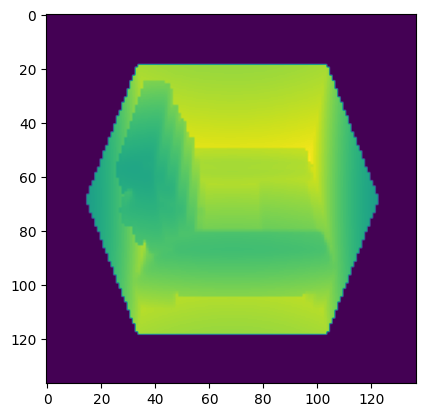

In [89]:
# --- minimal "run it" snippet for your DEPR-style renderer ---

import torch
import torch.nn.functional as F

# 1) build intrinsics matrix K (3x3) from your Intrin
def K_from_Intrin(intrin, device):
    return torch.tensor([[float(intrin.fx), 0.0, float(intrin.cx)],
                         [0.0, float(intrin.fy), float(intrin.cy)],
                         [0.0, 0.0, 1.0]], dtype=torch.float32, device=device)

# 2) inputs
device   = "cuda" if torch.cuda.is_available() else "cpu"
H = W    = image_size
K        = K_from_Intrin(intrins_full, device)

# camera pose (object frame): pull the camera back a bit and look toward +z
# cam2obj = torch.eye(4, dtype=torch.float32, device=device)
# cam2obj[2, 3] = -5.0  # translate along -z; increase magnitude if too close

center  = torch.zeros(3, device=device)
cam2obj = orbit_cam2obj(center, dist=4, yaw_deg=0, pitch_deg=45).to(device)

# voxel probs in [-1,1]
probvox = torch.from_numpy(binvoxes[0]).to(device) if isinstance(binvoxes[0], np.ndarray) else binvoxes[0].to(device)

# 3) set up DEPR-style modules you pasted (UniformSampler, OccupancyDensity, Renderer)
sampler = UniformSampler(N_samples=768).to(device)
density = OccupancyDensity(sigma=140.0).to(device)
renderer = Renderer(sampler=sampler, density=density, height=H, width=W, device=device).to(device)

# 4) render (probability path)
depth_map = renderer.render_depth_from_prob(
    intrinsic=K,
    cam2obj=cam2obj,
    probvox_m1p1=probvox,   # (Z,Y,X) in [-1,1]
    depth_scale=1.0,
    bound=1.0,
    tau=12.0
)
# depth_map: (H, W), differentiable w.r.t. probvox
print(type(depth_map), depth_map.shape)
# plot depth_map 
plt.imshow(depth_map.cpu())
plt.show()


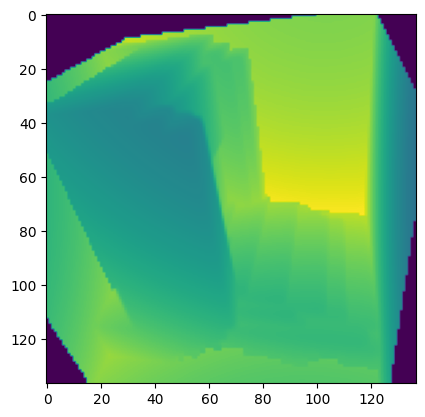

In [ ]:
# plot depth_map 
plt.imshow(depth_map.cpu())
plt.show()


In [100]:
print(depth_map.min().item(), depth_map.max().item(), (depth_map>0).float().mean().item())


1.9198423624038696 3.026010036468506 0.9999999403953552


In [107]:
# test differentiablity 

# assume probvox is your [-1,1] tensor (requires_grad=True)
probvox = probvox.clone().detach().to(device).requires_grad_(True)

depth_map, _, _ = render_depth_from_probvox_diff(
    probvox, intrins_full, cam2obj, image_size, image_size,
    n_samples=256, sigma=140.0, tau=12.0, device=device
)

# make a toy loss: sum of all depths
loss = depth_map.sum()
loss.backward()

print("loss:", loss.item())
print("grad shape:", probvox.grad.shape)
print("nonzero grads:", (probvox.grad.abs() > 1e-9).float().mean().item())


loss: 104253.0390625
grad shape: torch.Size([32, 32, 32])
nonzero grads: 0.33740234375


In [109]:
# === Differentiability checks (drop-in) ===
# Precompute a fixed box (no-grad), then test autograd + finite-diff at one voxel.

# 0) inputs
device = "cuda" if torch.cuda.is_available() else "cpu"
H = W = image_size
probvox = (torch.from_numpy(binvoxes[0]) if isinstance(binvoxes[0], np.ndarray) else binvoxes[0]).to(device)
cam2obj = look_at(torch.tensor([2.0, 1.2, -2.2], device=device))

with torch.no_grad():
    center, half = compute_soft_bounds(((probvox + 1.0) / 2.0))  # constant AABB

# 1) make a callable that keeps AABB fixed (so grads flow only to the field)
def render_depth_fixed_box(p):
    out, _, _ = render_depth_from_probvox_diff(
        p, intrins_full, cam2obj, H, W,
        n_samples=512, sigma=140.0, tau=12.0,
        center=center, half=half, device=device
    )
    return out

# 2) autograd test: backprop a simple scalar loss
p = probvox.detach().clone().requires_grad_(True)
D = render_depth_fixed_box(p)                         # (H,W)
loss = D.mean()                                       # any scalar works
loss.backward()

print("loss:", float(loss))
print("grad ratio nonzero:", (p.grad.abs() > 1e-9).float().mean().item())
print("grad min/max:", p.grad.min().item(), p.grad.max().item())

# --- FIXED finite-difference check (drop-in replacement for step 3) ---
# uses torch.argmax + torch.unravel_index; no TypeError

# 3) finite-difference check at the voxel with largest |grad|
g = p.grad.abs()
lin = torch.argmax(g)                                  # linear index
z, y, x = torch.unravel_index(lin, g.shape)            # 3D index (Z,Y,X)
z, y, x = int(z), int(y), int(x)

eps = 1e-3
with torch.no_grad():
    p_plus  = p.detach().clone();  p_plus[z, y, x]  += eps
    p_minus = p.detach().clone();  p_minus[z, y, x] -= eps

num = (render_depth_fixed_box(p_plus).mean() - render_depth_fixed_box(p_minus).mean()) / (2 * eps)
ana = p.grad[z, y, x]

print("voxel index (z,y,x):", (z, y, x))
print("autograd grad:", float(ana))
print("finite-diff  :", float(num))
print("relative err :", float((ana - num).abs() / (num.abs() + 1e-12)))


loss: 1.5424411296844482
grad ratio nonzero: 0.0062255859375
grad min/max: -8.088132941175274e-10 0.003343029646202922
voxel index (z,y,x): (31, 15, 13)
autograd grad: 0.003343029646202922
finite-diff  : 0.0032782552298158407
relative err : 0.019758807495236397


# loading real image